In [1]:
# AQI DATA SET
import pandas as pd

In [2]:
df = pd.read_csv("globalAirQuality.csv")

# Analysing Data
# df.head()
# df.tail()

df.describe()
# df.columns

# Selecting the data
# Columns
df["country"]
df[["city", "aqi"]]

# Rows
df.loc[0]
df.loc[0:2]  #start idx : end idx (ending indx included)

df.iloc[2]
df.iloc[0:2]  #start idx : end idx (ending indx not included)

# Cells - row, columns
df.loc[0:2, ["city"]]
df.columns

# df.iloc[0:3, 2]
df.loc[0:2,["country","city","latitude","longitude"]]
df.iloc[0:3, 1:5]

# Cell
df.at[0,"city"]
df.iat[0,2]

# copy
cities = df["city"].copy()
cities[0] = "Mumbai" #copy ban gaya original data mei no change woh safe hai
cities

0          Mumbai
1        New York
2        New York
3        New York
4        New York
           ...   
17995      Zurich
17996      Zurich
17997      Zurich
17998      Zurich
17999      Zurich
Name: city, Length: 18000, dtype: object

In [3]:
# Filtering Data
df[ df["aqi"]> 100]

df[ (df["aqi"] > 100) & ( df["temperature"] > 30)]

# -----row------------columns-------
aqi_data = df[ (df["aqi"] > 100) & ( df["temperature"] > 30)] [["city","aqi"]]

aqi_data
aqi_data.iloc[0]
aqi_data.loc[6]

city    New York
aqi          155
Name: 6, dtype: object

In [4]:
# Query Method

aqi_val = 100
df.query("aqi > 100 & temperature > 30")[["city", "aqi"]]
df.query("aqi > @aqi_val & temperature > 30")[["city", "aqi"]]

,city,aqi
6,New York,155
7,New York,115
14,New York,121
17,New York,127
25,New York,113
...,...,...
17947,Zurich,107
17950,Zurich,140
17975,Zurich,111
17976,Zurich,146


In [5]:
# Cleaning Data - Missing Values

df = pd.read_csv("raw_data.csv")
df

df.isnull() #-> Jahan Null hota hai wahan True show krta hai baaki jagah false
df.isnull().sum()
# df.dropna(axis = 1)
df.dropna()
df.fillna(182)


# Storing Cleaned DataFrame
cleaned_data = df.copy()
age_mean = cleaned_data["age"].mean()
cleaned_data["age"] = df["age"].fillna(age_mean)

df.ffill()
df.bfill()

,id,name,age,country,gender,income
0,1,John doe,29.0,USA,Male,55000.0
1,1,John doe,29.0,USA,Male,55000.0
2,2,Jane Smith,34.0,Canada,Female,62000.0
3,3,Alex,34.0,USA,Male,47000.0
4,4,Maria Garcia,34.0,Spain,Female,51000.0
5,5,Li Wei,27.0,China,Male,51000.0
6,6,Ahmed Khan,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,USA,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Fluiz,31.0,Mexico,Male,45000.0


In [6]:
# Handle Duplicates

# df[["country","gender"]].duplicated()
df["name"].duplicated()
df.drop_duplicates(inplace=True)
df

,id,name,age,country,gender,income
0,1,John doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Male,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Fluiz,NaN,Mexico,Male,45000.0
10,10,Emily Davis,31.0,USA,NaN,58000.0


In [7]:
# Data Types

df.dtypes

df2 = df.copy()

df2 = df2.fillna(0)
df2 = df2["age"].astype("int64").copy()
df2.dtypes

dtype('int64')

In [8]:
aqi_data = pd.read_csv("globalAirQuality.csv")
aqi_data["timestamp"] = pd.to_datetime(aqi_data["timestamp"])

aqi_data["timestamp"].dtype

dtype('<M8[ns]')

In [9]:
date_str = pd.Series(pd.to_datetime("2026-12-31"))
type(date_str.dtypes)

numpy.dtypes.DateTime64DType

In [10]:
df["gender"].str.capitalize()

df["name"].str.split(" ")

df["country"].str.contains("india",case = False)

0     False
2     False
3     False
4     False
5     False
6      True
7       NaN
8     False
9     False
10    False
Name: country, dtype: object

In [11]:
# Feature Engineering

df2 = df.copy()
df2["gender"] = df2["gender"].fillna("Unknown")

df2["tax"] = df2["income"].apply(lambda x : "20%" if x >= 50000 else "10%")


gender_map = {"Male" : "M", "Female" : "F" , "Unknown": "U"}
df2["gender"] = df2["gender"].map(gender_map)

df2 = df2.assign(new_income = df2["income"] * 1.1)

df2["country"] = df["country"].replace("USA","US")

df2.columns = ["ID","Name","Age","Country","Gender","Income","TAX","New_Income"]

df2.rename(columns={"Income" : "Salary"})
df2.rename(index={1:"First"})

# df2["Income"].sort_values()
df2 = df2.fillna(50)
df2.sort_values("Income")
# df2.sort_values("Income", ascending = False)

sorted_df = df2.sort_values(["Income","Age"])
sorted_df.sort_index()


# Reset
sorted_df.reset_index()
sorted_df.reset_index(drop = True)

# Ranking
sorted_df["Ranking"] = sorted_df["Income"].rank(ascending=False, method = "dense")
sorted_df[["ID","Name","Age","Country","New_Income","Income","TAX","Gender"]]

,ID,Name,Age,Country,New_Income,Income,TAX,Gender
4,4,Maria Garcia,34.0,Spain,50.0,50.0,10%,F
9,9,Carlos Fluiz,50.0,Mexico,49500.0,45000.0,10%,M
3,3,Alex,50.0,US,51700.0,47000.0,10%,M
5,5,Li Wei,27.0,China,56100.0,51000.0,20%,M
0,1,John doe,29.0,US,60500.0,55000.0,20%,M
10,10,Emily Davis,31.0,US,63800.0,58000.0,20%,U
8,8,Rachel Lee,29.0,US,68200.0,62000.0,20%,F
2,2,Jane Smith,50.0,Canada,68200.0,62000.0,20%,F
7,7,Ahmed Khan,38.0,50,74800.0,68000.0,20%,M
6,6,50,45.0,India,80300.0,73000.0,20%,F


In [12]:





# --------------------------------------------------------TASK--------------------------------------------------------
# shift id column to the end

df2 = df.copy()

new_col_order = [col for col in df2.columns if col != "id"] + ["id"]
print(new_col_order)

df2[new_col_order]

['name', 'age', 'country', 'gender', 'income', 'id']


,name,age,country,gender,income,id
0,John doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Male,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Fluiz,NaN,Mexico,Male,45000.0,9
10,Emily Davis,31.0,USA,NaN,58000.0,10


In [13]:
df2 = df2[["name","age","country","gender","income","id"]]
df2

,name,age,country,gender,income,id
0,John doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Male,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Fluiz,NaN,Mexico,Male,45000.0,9
10,Emily Davis,31.0,USA,NaN,58000.0,10


In [14]:
df2 = df.copy()

df2.drop_duplicates(inplace = True)
df2.fillna(0,inplace = True)
df2 = df2.sort_values("income")
df2.reset_index(drop = True,inplace = True)


df2.to_csv("sorted_data.csv")

In [15]:
#--------------------------------------------Group By--------------------------------------------

df.groupby("country" )["income"].min()
df.groupby("country" )["income"].max()

df.groupby("gender")["age"].min()
df.groupby("gender")["income"].max()


df.groupby("country" )["income"].agg(["mean","min","max"])
df.groupby("country" )["income"].aggregate(["mean","min","max"]) #Both performs the same task

df.groupby("country" )["income"].agg(avg_salary= "mean", min_salary = "min",max_salary="max")


# Group By ke saath 2 alag chizo ka aggregate function use krna
df.groupby("country").agg({
    "income" : "mean",
    "age" : "mean"
})

df.groupby("country").agg({
    "income" : "max",
    "age" : "mean"
})



# Column renaming after operation
df.groupby("country").agg(
    max_salary = ("income" , "max"),
    avg_age = ("age" , "mean")
)

,max_salary,avg_age
country,,
Canada,62000.0,NaN
China,51000.0,27.000000
India,73000.0,45.000000
Mexico,45000.0,NaN
Spain,NaN,34.000000
USA,62000.0,29.666667


In [16]:
# MELT AND PIVOT FOR RESHAPING

df = pd.DataFrame({
    "country":["USA", "USA", "India", "India"],
    "year" : [2020, 2021, 2020, 2021],
    "sales" : [100, 120, 90, 110],
    "profit" : [20, 25, 18, 22]
})

melted_data = df.melt(
    id_vars = ["country", "year"],
    value_vars=["sales","profit"],
    var_name = "Matrix",
    value_name = "value"
)

In [17]:
melted_data.pivot(
    index = ["country","year"],
    columns = "Matrix",
    values = "value"
)

Matrix        profit  sales
country year               
India   2020      18     90
        2021      22    110
USA     2020      20    100
        2021      25    120

In [18]:
melted_data

,country,year,Matrix,value
0,USA,2020,sales,100
1,USA,2021,sales,120
2,India,2020,sales,90
3,India,2021,sales,110
4,USA,2020,profit,20
5,USA,2021,profit,25
6,India,2020,profit,18
7,India,2021,profit,22


In [19]:
df

,country,year,sales,profit
0,USA,2020,100,20
1,USA,2021,120,25
2,India,2020,90,18
3,India,2021,110,22


<Axes: xlabel='Age', ylabel='Salary'>

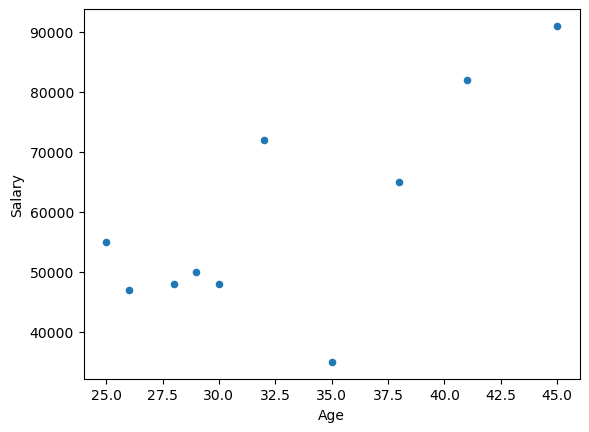

In [26]:
# --------------------------------------------DATA VISUALIAZTION--------------------------------------------
df = pd.read_csv("employee_data.csv")

# df["Age"].hist()

df.plot(kind="scatter", x="Age", y="Salary")

In [23]:
df

,ID,Name,Age,Department,Salary
0,1,Alice,25,HR,55000
1,2,Bob,32,IT,72000
2,3,Charlie,28,Finance,48000
3,4,David,45,Marketing,91000
4,5,Eva,38,IT,65000
5,6,Frank,29,Finance,50000
6,7,Grace,41,HR,82000
7,8,Hannah,26,Marketing,47000
8,9,Ian,35,IT,35000
9,10,Julia,30,Finance,48000


In [36]:
# -----------------------------------------------------MERGING AND JOINING OF DATA-----------------------------------------------------
df_customers = pd.DataFrame({
    "customer_id":[1,2,3,4],
    "name":["Adam","Bob","Charlie","Dave"]
})

df_orders = pd.DataFrame({
    "order_id":[101,102,103,104],
    "customer_id":[2,1,4,5],
    "amount" : [250,120,300,100]
})

pd.merge(df_customers, df_orders, on="customer_id") #inner Join
pd.merge(df_customers, df_orders, on="customer_id", how="left") #Left Join
pd.merge(df_customers, df_orders, on="customer_id", how="right") #right Join
pd.merge(df_customers, df_orders, on="customer_id", how="outer") #outer Join

,customer_id,name,order_id,amount
0,1,Adam,102.0,120.0
1,2,Bob,101.0,250.0
2,3,Charlie,NaN,NaN
3,4,Dave,103.0,300.0
4,5,NaN,104.0,100.0


In [37]:
df_customers

,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [38]:
df_orders

,order_id,customer_id,amount
0,101,2,250
1,102,1,120
2,103,4,300
3,104,5,100


In [53]:
# Concatentation

df1 = pd.DataFrame({
    "id" : [1, 2, 3],
    "name" : ["Adam" , "Eve" , "Bob"]
})

df2 = pd.DataFrame({
    "id" : [4, 5, 6],
    "name" : ["Charlie" , "Fester" , "Gillian"]
})

pd.concat([df1,df2]) #Row wise concatentation
pd.concat([df1,df2], ignore_index=True)

pd.concat([df1,df2] , axis = 1)

,id,name,id,name
0,1,Adam,4,Charlie
1,2,Eve,5,Fester
2,3,Bob,6,Gillian


In [49]:
df1

,id,name
0,1,Adam
1,2,Eve
2,3,Bob


In [50]:
df2

,id,name
0,4,Charlie
1,5,Fester
2,6,Gillian
